# Importing Necessary Libraries

In [1]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn



# Loading Data

In [2]:
# load dataset from huggingface
data = load_dataset("KintsugiHealth/dam-dataset")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/918k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/800k [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/8113 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7034 [00:00<?, ? examples/s]

In [3]:
print(data)

DatasetDict({
    validation: Dataset({
        features: ['user', 'age', 'ethnicity', 'gender', 'phq1', 'phq2', 'phq3', 'phq4', 'phq5', 'phq6', 'phq7', 'phq8', 'phq9', 'phq', 'phq_2', 'gad1', 'gad2', 'gad3', 'gad4', 'gad5', 'gad6', 'gad7', 'gad', 'gad_2', 'duration', 'prompt_vad_cut_duration', 'prompt_vad_trimmed_duration', 'conversational_vad_cut_duration', 'conversational_vad_trimmed_duration', 'mos_pred', 'noi_pred', 'loud_pred', 'dis_pred', 'col_pred', 'bin_phq', 'bin_gad', 'split', 'prompt', 'state', 'income', 'english_preferred', 'preferred_lang', 'scores_anxiety', 'quantized_labels_anxiety', 'scores_depression', 'quantized_labels_depression', 'is_unbiased'],
        num_rows: 8113
    })
    test: Dataset({
        features: ['user', 'age', 'ethnicity', 'gender', 'phq1', 'phq2', 'phq3', 'phq4', 'phq5', 'phq6', 'phq7', 'phq8', 'phq9', 'phq', 'phq_2', 'gad1', 'gad2', 'gad3', 'gad4', 'gad5', 'gad6', 'gad7', 'gad', 'gad_2', 'duration', 'prompt_vad_cut_duration', 'prompt_vad_trimmed

In [4]:
df_val = data["validation"].to_pandas()
df_test = data["test"].to_pandas()

# merge
df = pd.concat([df_val, df_test], ignore_index=True)

In [ ]:
df.head()

,user,age,ethnicity,gender,phq1,phq2,phq3,phq4,phq5,phq6,...,prompt,state,income,english_preferred,preferred_lang,scores_anxiety,quantized_labels_anxiety,scores_depression,quantized_labels_depression,is_unbiased
0,12a88770ccb9e8b1b92266427ed11931,63,Other,Female,3.0,3.0,2.0,3,2,3,...,None,None,None,None,None,-0.103333,3,-0.335449,2,True
1,6e5e3788d1e62f208855e5065186d2e6,66,White,Male,0.0,0.0,0.0,0,0,0,...,None,None,None,None,None,-1.737305,0,-1.913086,0,True
2,d7fb7d47662fe32c75df62434f2d53bf,53,White,Male,1.0,0.0,1.0,1,0,0,...,None,None,None,None,None,-1.304688,0,-1.494141,0,True
3,4b9738bc7f45c23dd6b9f67731a35c87,52,White,Female,0.0,1.0,1.0,0,1,1,...,None,None,None,None,None,-0.973633,0,-1.247070,0,True
4,5406c3e92baa10e95bfc10d7ce02ec0a,62,White,Male,0.0,0.0,0.0,0,0,0,...,None,None,None,None,None,-2.814453,0,-2.968750,0,True


In [5]:
df.shape

(15147, 47)

In [6]:
df.columns

Index(['user', 'age', 'ethnicity', 'gender', 'phq1', 'phq2', 'phq3', 'phq4',
       'phq5', 'phq6', 'phq7', 'phq8', 'phq9', 'phq', 'phq_2', 'gad1', 'gad2',
       'gad3', 'gad4', 'gad5', 'gad6', 'gad7', 'gad', 'gad_2', 'duration',
       'prompt_vad_cut_duration', 'prompt_vad_trimmed_duration',
       'conversational_vad_cut_duration',
       'conversational_vad_trimmed_duration', 'mos_pred', 'noi_pred',
       'loud_pred', 'dis_pred', 'col_pred', 'bin_phq', 'bin_gad', 'split',
       'prompt', 'state', 'income', 'english_preferred', 'preferred_lang',
       'scores_anxiety', 'quantized_labels_anxiety', 'scores_depression',
       'quantized_labels_depression', 'is_unbiased'],
      dtype='object')

# Renaming Columns

In [7]:
df = df.rename(columns={

    # demographics
    "user": "patient_id",
    "age": "age",
    "gender": "gender",
    "ethnicity": "ethnicity",
    "income": "income_level",
    "state": "location",

    # PHQ questions
    "phq1": "phq_little_interest",
    "phq2": "phq_feeling_down",
    "phq3": "phq_sleep_issues",
    "phq4": "phq_low_energy",
    "phq5": "phq_appetite",
    "phq6": "phq_self_worth",
    "phq7": "phq_concentration",
    "phq8": "phq_psychomotor",
    "phq9": "phq_suicidal_thoughts",

    "phq": "phq_total_score",

    # GAD questions
    "gad1": "gad_nervous",
    "gad2": "gad_uncontrollable_worry",
    "gad3": "gad_excessive_worry",
    "gad4": "gad_trouble_relaxing",
    "gad5": "gad_restlessness",
    "gad6": "gad_irritability",
    "gad7": "gad_fear",

    "gad": "gad_total_score",

    # labels
    "scores_depression": "depression_score",
    "scores_anxiety": "anxiety_score",
    "quantized_labels_depression": "depression_severity",
    "quantized_labels_anxiety": "anxiety_severity",
    "bin_phq": "depression_binary",
    "bin_gad": "anxiety_binary"
})

In [8]:
print("\nRenamed columns:")
print(df.columns)


Renamed columns:
Index(['patient_id', 'age', 'ethnicity', 'gender', 'phq_little_interest',
       'phq_feeling_down', 'phq_sleep_issues', 'phq_low_energy',
       'phq_appetite', 'phq_self_worth', 'phq_concentration',
       'phq_psychomotor', 'phq_suicidal_thoughts', 'phq_total_score', 'phq_2',
       'gad_nervous', 'gad_uncontrollable_worry', 'gad_excessive_worry',
       'gad_trouble_relaxing', 'gad_restlessness', 'gad_irritability',
       'gad_fear', 'gad_total_score', 'gad_2', 'duration',
       'prompt_vad_cut_duration', 'prompt_vad_trimmed_duration',
       'conversational_vad_cut_duration',
       'conversational_vad_trimmed_duration', 'mos_pred', 'noi_pred',
       'loud_pred', 'dis_pred', 'col_pred', 'depression_binary',
       'anxiety_binary', 'split', 'prompt', 'location', 'income_level',
       'english_preferred', 'preferred_lang', 'anxiety_score',
       'anxiety_severity', 'depression_score', 'depression_severity',
       'is_unbiased'],
      dtype='object')


In [9]:
df.to_csv("mental_health.csv", index=False)

# Exploratory Data Analysis

In [10]:
df = pd.read_csv("mental_health.csv")


In [11]:
print("Shape:", df.shape)
df.head(20)

Shape: (15147, 47)


,patient_id,age,ethnicity,gender,phq_little_interest,phq_feeling_down,phq_sleep_issues,phq_low_energy,phq_appetite,phq_self_worth,...,prompt,location,income_level,english_preferred,preferred_lang,anxiety_score,anxiety_severity,depression_score,depression_severity,is_unbiased
0,12a88770ccb9e8b1b92266427ed11931,63,Other,Female,3.0,3.0,2.0,3,2,3,...,NaN,NaN,NaN,NaN,NaN,-0.103333,3,-0.335449,2,True
1,6e5e3788d1e62f208855e5065186d2e6,66,White,Male,0.0,0.0,0.0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,-1.737305,0,-1.913086,0,True
2,d7fb7d47662fe32c75df62434f2d53bf,53,White,Male,1.0,0.0,1.0,1,0,0,...,NaN,NaN,NaN,NaN,NaN,-1.304688,0,-1.494141,0,True
3,4b9738bc7f45c23dd6b9f67731a35c87,52,White,Female,0.0,1.0,1.0,0,1,1,...,NaN,NaN,NaN,NaN,NaN,-0.973633,0,-1.247070,0,True
4,5406c3e92baa10e95bfc10d7ce02ec0a,62,White,Male,0.0,0.0,0.0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,-2.814453,0,-2.968750,0,True
5,054271df09032843353e9945a8faecd2,58,White,Male,0.0,0.0,0.0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,-2.787109,0,-2.941406,0,True
6,c5301aa02904a828748e1809697865c3,43,White,Male,1.0,1.0,1.0,1,1,0,...,NaN,NaN,NaN,NaN,NaN,-1.258789,0,-1.544922,0,True
7,4585c018edb2448c3ff93ebe85f79609,19,Other or mixed race,Female,0.0,0.0,1.0,0,1,1,...,NaN,NaN,NaN,NaN,NaN,-1.709961,0,-1.956055,0,True
8,fbf09baf3edc85de0763d539054287e0,69,White,Male,0.0,0.0,0.0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,-2.191406,0,-2.357422,0,True
9,107fa9842d4ac797c3a61ad866ef4058,66,White,Female,1.0,1.0,2.0,2,1,0,...,NaN,NaN,NaN,NaN,NaN,-1.099609,0,-1.415039,0,True


In [12]:
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15147 entries, 0 to 15146
Data columns (total 47 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   patient_id                           15147 non-null  object 
 1   age                                  15147 non-null  int64  
 2   ethnicity                            15143 non-null  object 
 3   gender                               15147 non-null  object 
 4   phq_little_interest                  15147 non-null  float64
 5   phq_feeling_down                     15147 non-null  float64
 6   phq_sleep_issues                     15147 non-null  float64
 7   phq_low_energy                       15147 non-null  int64  
 8   phq_appetite                         15147 non-null  int64  
 9   phq_self_worth                       15147 non-null  int64  
 10  phq_concentration                    15147 non-null  int64  
 11  phq_psychomot

In [13]:
print("\nDescriptive Statistics:")
df.describe()


Descriptive Statistics:


,age,phq_little_interest,phq_feeling_down,phq_sleep_issues,phq_low_energy,phq_appetite,phq_self_worth,phq_concentration,phq_psychomotor,phq_suicidal_thoughts,...,noi_pred,loud_pred,dis_pred,col_pred,depression_binary,anxiety_binary,anxiety_score,anxiety_severity,depression_score,depression_severity
count,15147.000000,15147.000000,15147.000000,15147.000000,15147.000000,15147.000000,15147.000000,15147.000000,15147.000000,15147.000000,...,15147.000000,15147.000000,15147.000000,15147.000000,15147.000000,15147.000000,15147.000000,15147.000000,15147.000000,15147.000000
mean,45.793490,1.054730,1.030765,1.352677,1.413811,1.028454,0.998019,0.925662,0.509210,0.379283,...,3.551740,3.615430,3.710008,3.405189,0.386677,0.407209,-0.801249,1.081732,-1.022037,0.594375
std,17.271609,0.975997,0.981933,1.082434,1.026013,1.061142,1.066579,1.027944,0.844251,0.779034,...,0.658180,0.705361,0.819481,0.733077,0.487005,0.491331,0.744732,1.105931,0.747307,0.810267
min,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.492622,1.120808,1.007258,1.474991,0.000000,0.000000,-3.181641,0.000000,-3.314453,0.000000
25%,31.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,3.157492,3.118737,3.097453,2.801278,0.000000,0.000000,-1.333984,0.000000,-1.564453,0.000000
50%,43.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,...,3.704386,3.717527,4.012892,3.479711,0.000000,0.000000,-0.697754,1.000000,-0.936523,0.000000
75%,61.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,0.000000,...,4.066601,4.210618,4.375742,4.056630,1.000000,1.000000,-0.239990,2.000000,-0.463745,1.000000
max,99.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,...,4.728630,4.843781,4.960519,4.679049,1.000000,1.000000,1.096680,3.000000,1.087891,2.000000


# Data Preprocessing

In [14]:
print("\nMissing values")
print(df.isnull().sum())


Missing values
patient_id                                 0
age                                        0
ethnicity                                  4
gender                                     0
phq_little_interest                        0
phq_feeling_down                           0
phq_sleep_issues                           0
phq_low_energy                             0
phq_appetite                               0
phq_self_worth                             0
phq_concentration                          0
phq_psychomotor                            0
phq_suicidal_thoughts                      0
phq_total_score                            0
phq_2                                      0
gad_nervous                                0
gad_uncontrollable_worry                   0
gad_excessive_worry                        0
gad_trouble_relaxing                       0
gad_restlessness                           0
gad_irritability                           0
gad_fear                               

# Removing Unwanted Columns

In [15]:
# columns to remove
remove_cols = [
"phq_2","gad_2","duration",
"prompt_vad_cut_duration","prompt_vad_trimmed_duration",
"conversational_vad_cut_duration","conversational_vad_trimmed_duration",
"mos_pred","noi_pred","loud_pred","dis_pred","col_pred",
"split","prompt","english_preferred","preferred_lang","is_unbiased"
]

df.drop(columns=remove_cols, errors='ignore', inplace=True)

print("New shape:", df.shape)

df.to_csv("mental_health.csv", index=False)

New shape: (15147, 30)


In [16]:
df.columns

Index(['patient_id', 'age', 'ethnicity', 'gender', 'phq_little_interest',
       'phq_feeling_down', 'phq_sleep_issues', 'phq_low_energy',
       'phq_appetite', 'phq_self_worth', 'phq_concentration',
       'phq_psychomotor', 'phq_suicidal_thoughts', 'phq_total_score',
       'gad_nervous', 'gad_uncontrollable_worry', 'gad_excessive_worry',
       'gad_trouble_relaxing', 'gad_restlessness', 'gad_irritability',
       'gad_fear', 'gad_total_score', 'depression_binary', 'anxiety_binary',
       'location', 'income_level', 'anxiety_score', 'anxiety_severity',
       'depression_score', 'depression_severity'],
      dtype='object')

In [17]:
print(df.isnull().sum())

patient_id                     0
age                            0
ethnicity                      4
gender                         0
phq_little_interest            0
phq_feeling_down               0
phq_sleep_issues               0
phq_low_energy                 0
phq_appetite                   0
phq_self_worth                 0
phq_concentration              0
phq_psychomotor                0
phq_suicidal_thoughts          0
phq_total_score                0
gad_nervous                    0
gad_uncontrollable_worry       0
gad_excessive_worry            0
gad_trouble_relaxing           0
gad_restlessness               0
gad_irritability               0
gad_fear                       0
gad_total_score                0
depression_binary              0
anxiety_binary                 0
location                    5894
income_level                5894
anxiety_score                  0
anxiety_severity               0
depression_score               0
depression_severity            0
dtype: int

In [18]:
df["ethnicity"] = df["ethnicity"].fillna(df["ethnicity"].mode()[0])
df["location"] = df["location"].fillna("Unknown")
df["income_level"] = df["income_level"].fillna("Unknown")

In [19]:
print(df.isnull().sum())

patient_id                  0
age                         0
ethnicity                   0
gender                      0
phq_little_interest         0
phq_feeling_down            0
phq_sleep_issues            0
phq_low_energy              0
phq_appetite                0
phq_self_worth              0
phq_concentration           0
phq_psychomotor             0
phq_suicidal_thoughts       0
phq_total_score             0
gad_nervous                 0
gad_uncontrollable_worry    0
gad_excessive_worry         0
gad_trouble_relaxing        0
gad_restlessness            0
gad_irritability            0
gad_fear                    0
gad_total_score             0
depression_binary           0
anxiety_binary              0
location                    0
income_level                0
anxiety_score               0
anxiety_severity            0
depression_score            0
depression_severity         0
dtype: int64


In [20]:
df.shape

(15147, 30)

In [22]:
df = df.drop(columns=["patient_id", "age", "gender", "ethnicity", "location", "income_level"])

In [23]:
print(df.dtypes)

phq_little_interest         float64
phq_feeling_down            float64
phq_sleep_issues            float64
phq_low_energy                int64
phq_appetite                  int64
phq_self_worth                int64
phq_concentration             int64
phq_psychomotor             float64
phq_suicidal_thoughts         int64
phq_total_score             float64
gad_nervous                 float64
gad_uncontrollable_worry    float64
gad_excessive_worry         float64
gad_trouble_relaxing        float64
gad_restlessness            float64
gad_irritability            float64
gad_fear                    float64
gad_total_score             float64
depression_binary             int64
anxiety_binary                int64
anxiety_score               float64
anxiety_severity              int64
depression_score            float64
depression_severity           int64
dtype: object


# Checking for Data Class Imbalance

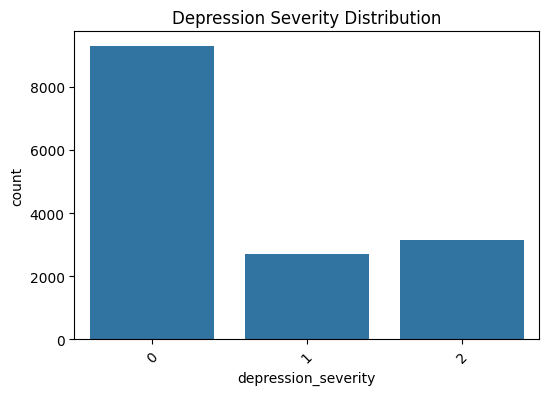

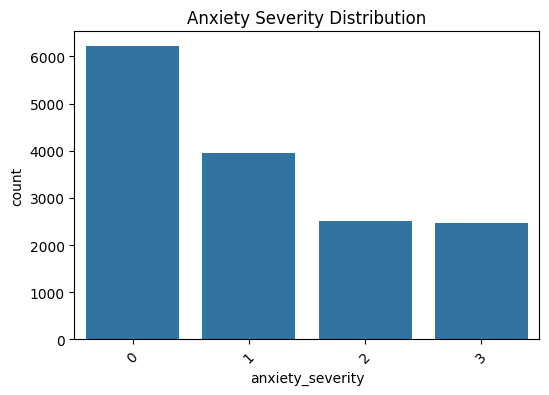

In [24]:
plt.figure(figsize=(6,4))
sns.countplot(x="depression_severity", data=df)
plt.title("Depression Severity Distribution")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x="anxiety_severity", data=df)
plt.title("Anxiety Severity Distribution")
plt.xticks(rotation=45)
plt.show()

# Handling Data Imbalance

In [25]:
from imblearn.over_sampling import SMOTE

X = df.drop(columns=["depression_severity","anxiety_severity"])
y = df["depression_severity"]

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

print("After SMOTE:")
print(y_res.value_counts())

After SMOTE:
depression_severity
2    9290
0    9290
1    9290
Name: count, dtype: int64


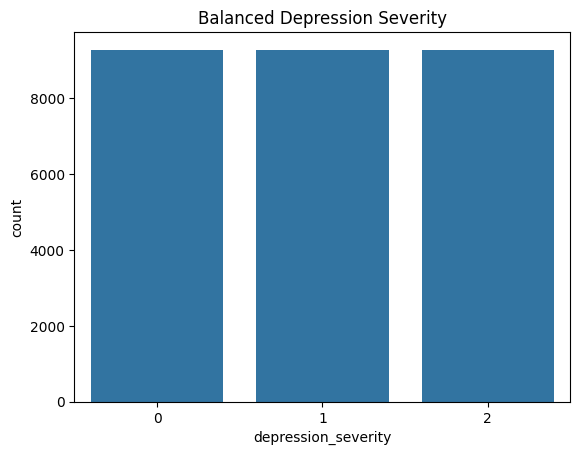

In [26]:
sns.countplot(x=y_res)
plt.title("Balanced Depression Severity")
plt.show()

In [27]:
X = df.drop(columns=["depression_severity","anxiety_severity"])
y_anx = df["anxiety_severity"]

In [28]:
smote = SMOTE(random_state=42)
X_res_anx, y_res_anx = smote.fit_resample(X, y_anx)

print("After SMOTE (Anxiety):")
print(y_res_anx.value_counts())

After SMOTE (Anxiety):
anxiety_severity
3    6220
0    6220
1    6220
2    6220
Name: count, dtype: int64


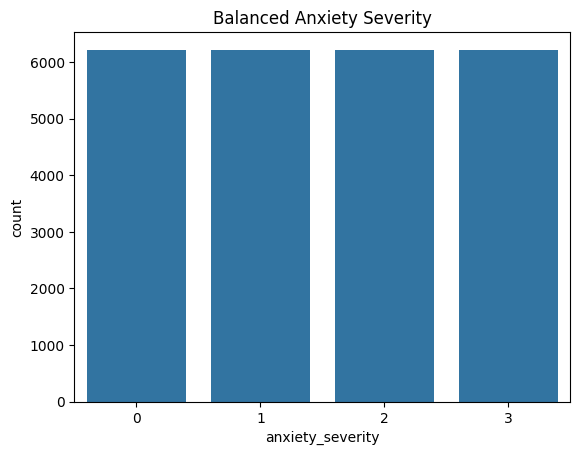

In [29]:
sns.countplot(x=y_res_anx)
plt.title("Balanced Anxiety Severity")
plt.show()

# Outlier Detection

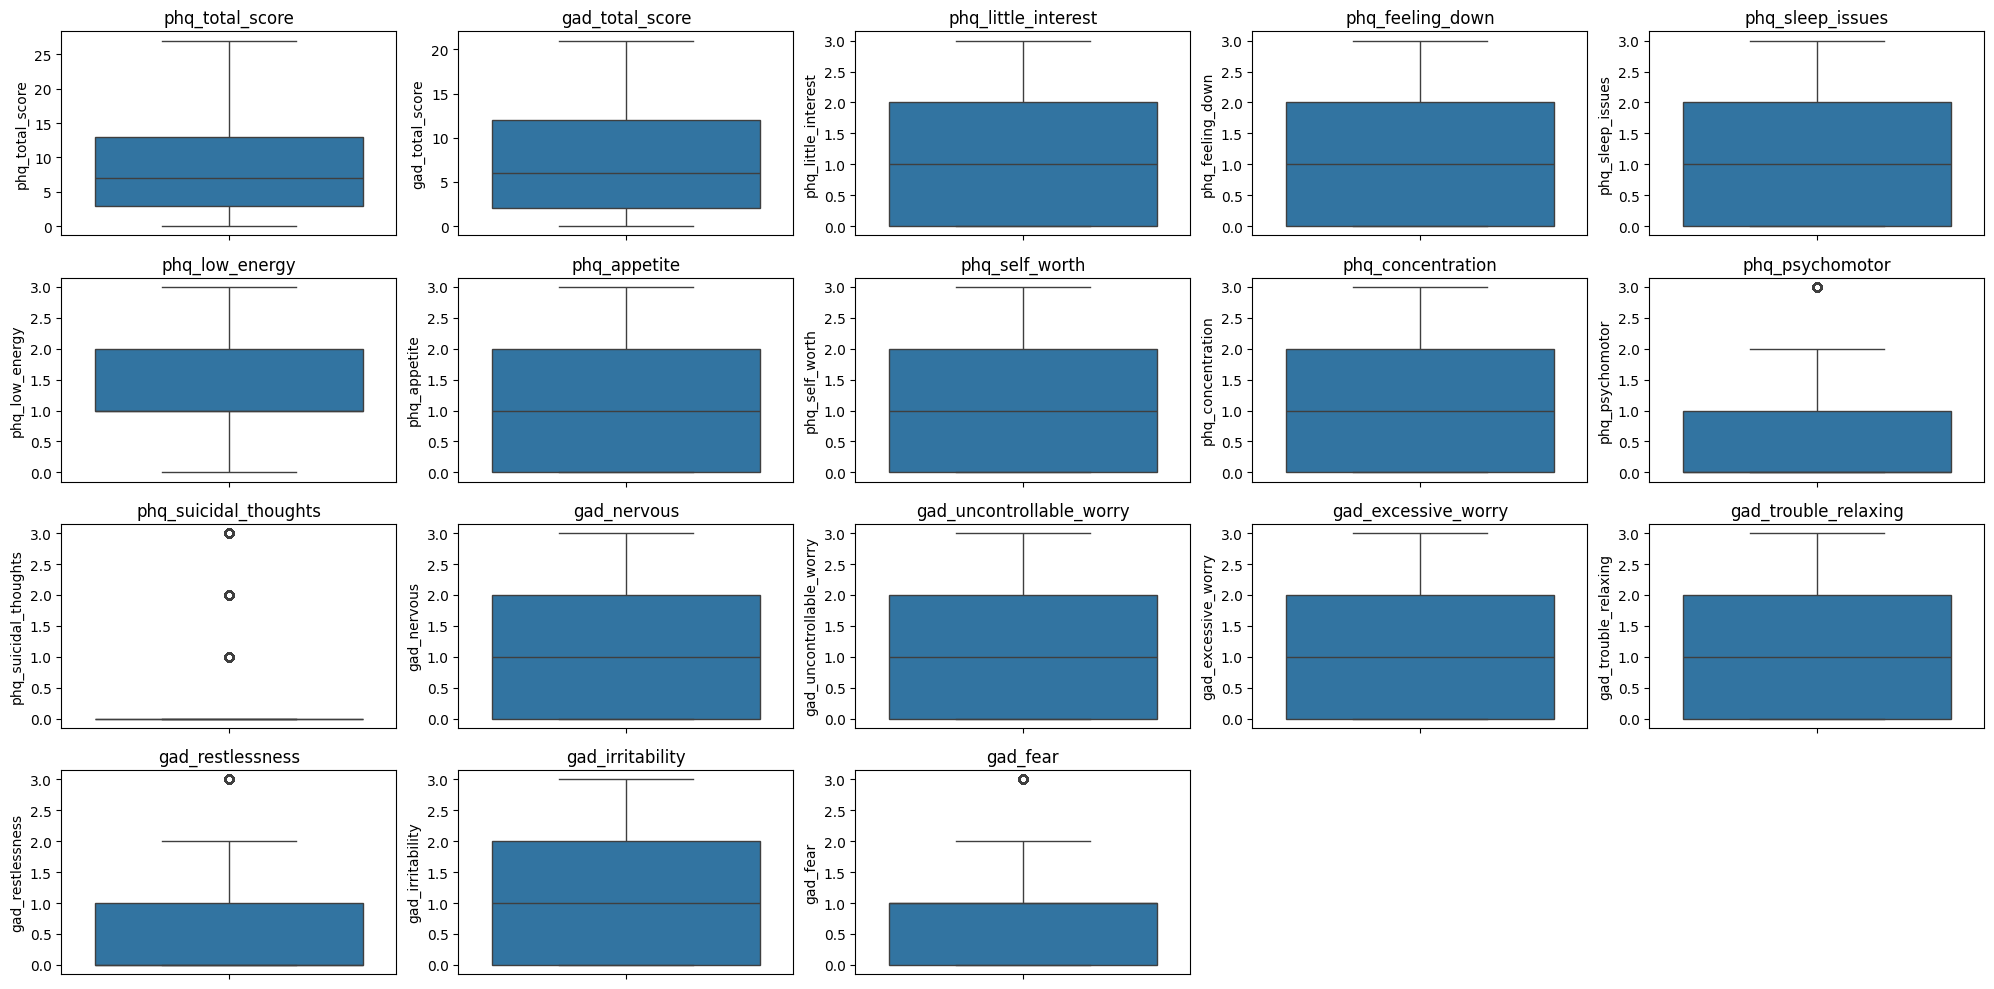

In [30]:
num_cols = [
"phq_total_score","gad_total_score",
"phq_little_interest","phq_feeling_down","phq_sleep_issues",
"phq_low_energy","phq_appetite","phq_self_worth",
"phq_concentration","phq_psychomotor","phq_suicidal_thoughts",
"gad_nervous","gad_uncontrollable_worry","gad_excessive_worry",
"gad_trouble_relaxing","gad_restlessness","gad_irritability","gad_fear"
]

plt.figure(figsize=(20,10))
for i,col in enumerate(num_cols):
    plt.subplot(4,5,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

# Outlier Treatment

In [31]:
# IQR Capping
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

print("Outlier treatment done")

Outlier treatment done


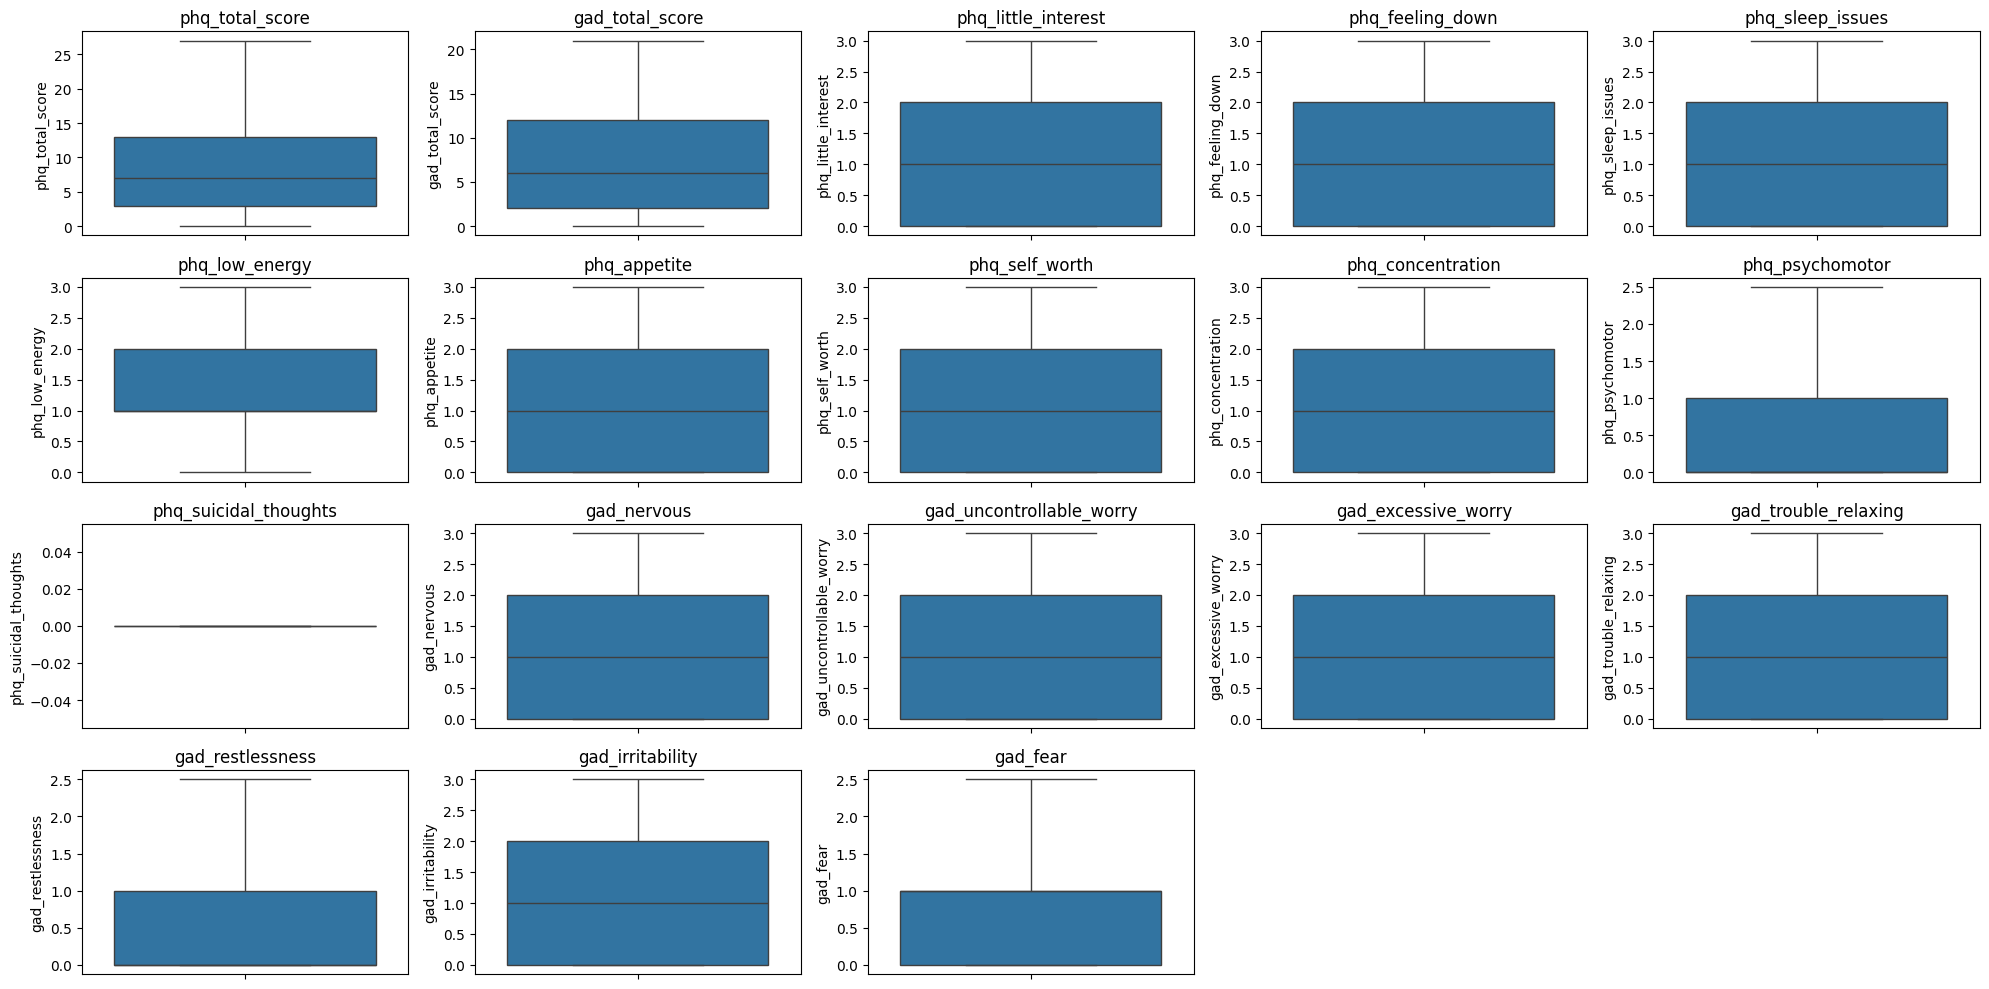

In [32]:
plt.figure(figsize=(20,10))
for i,col in enumerate(num_cols):
    plt.subplot(4,5,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

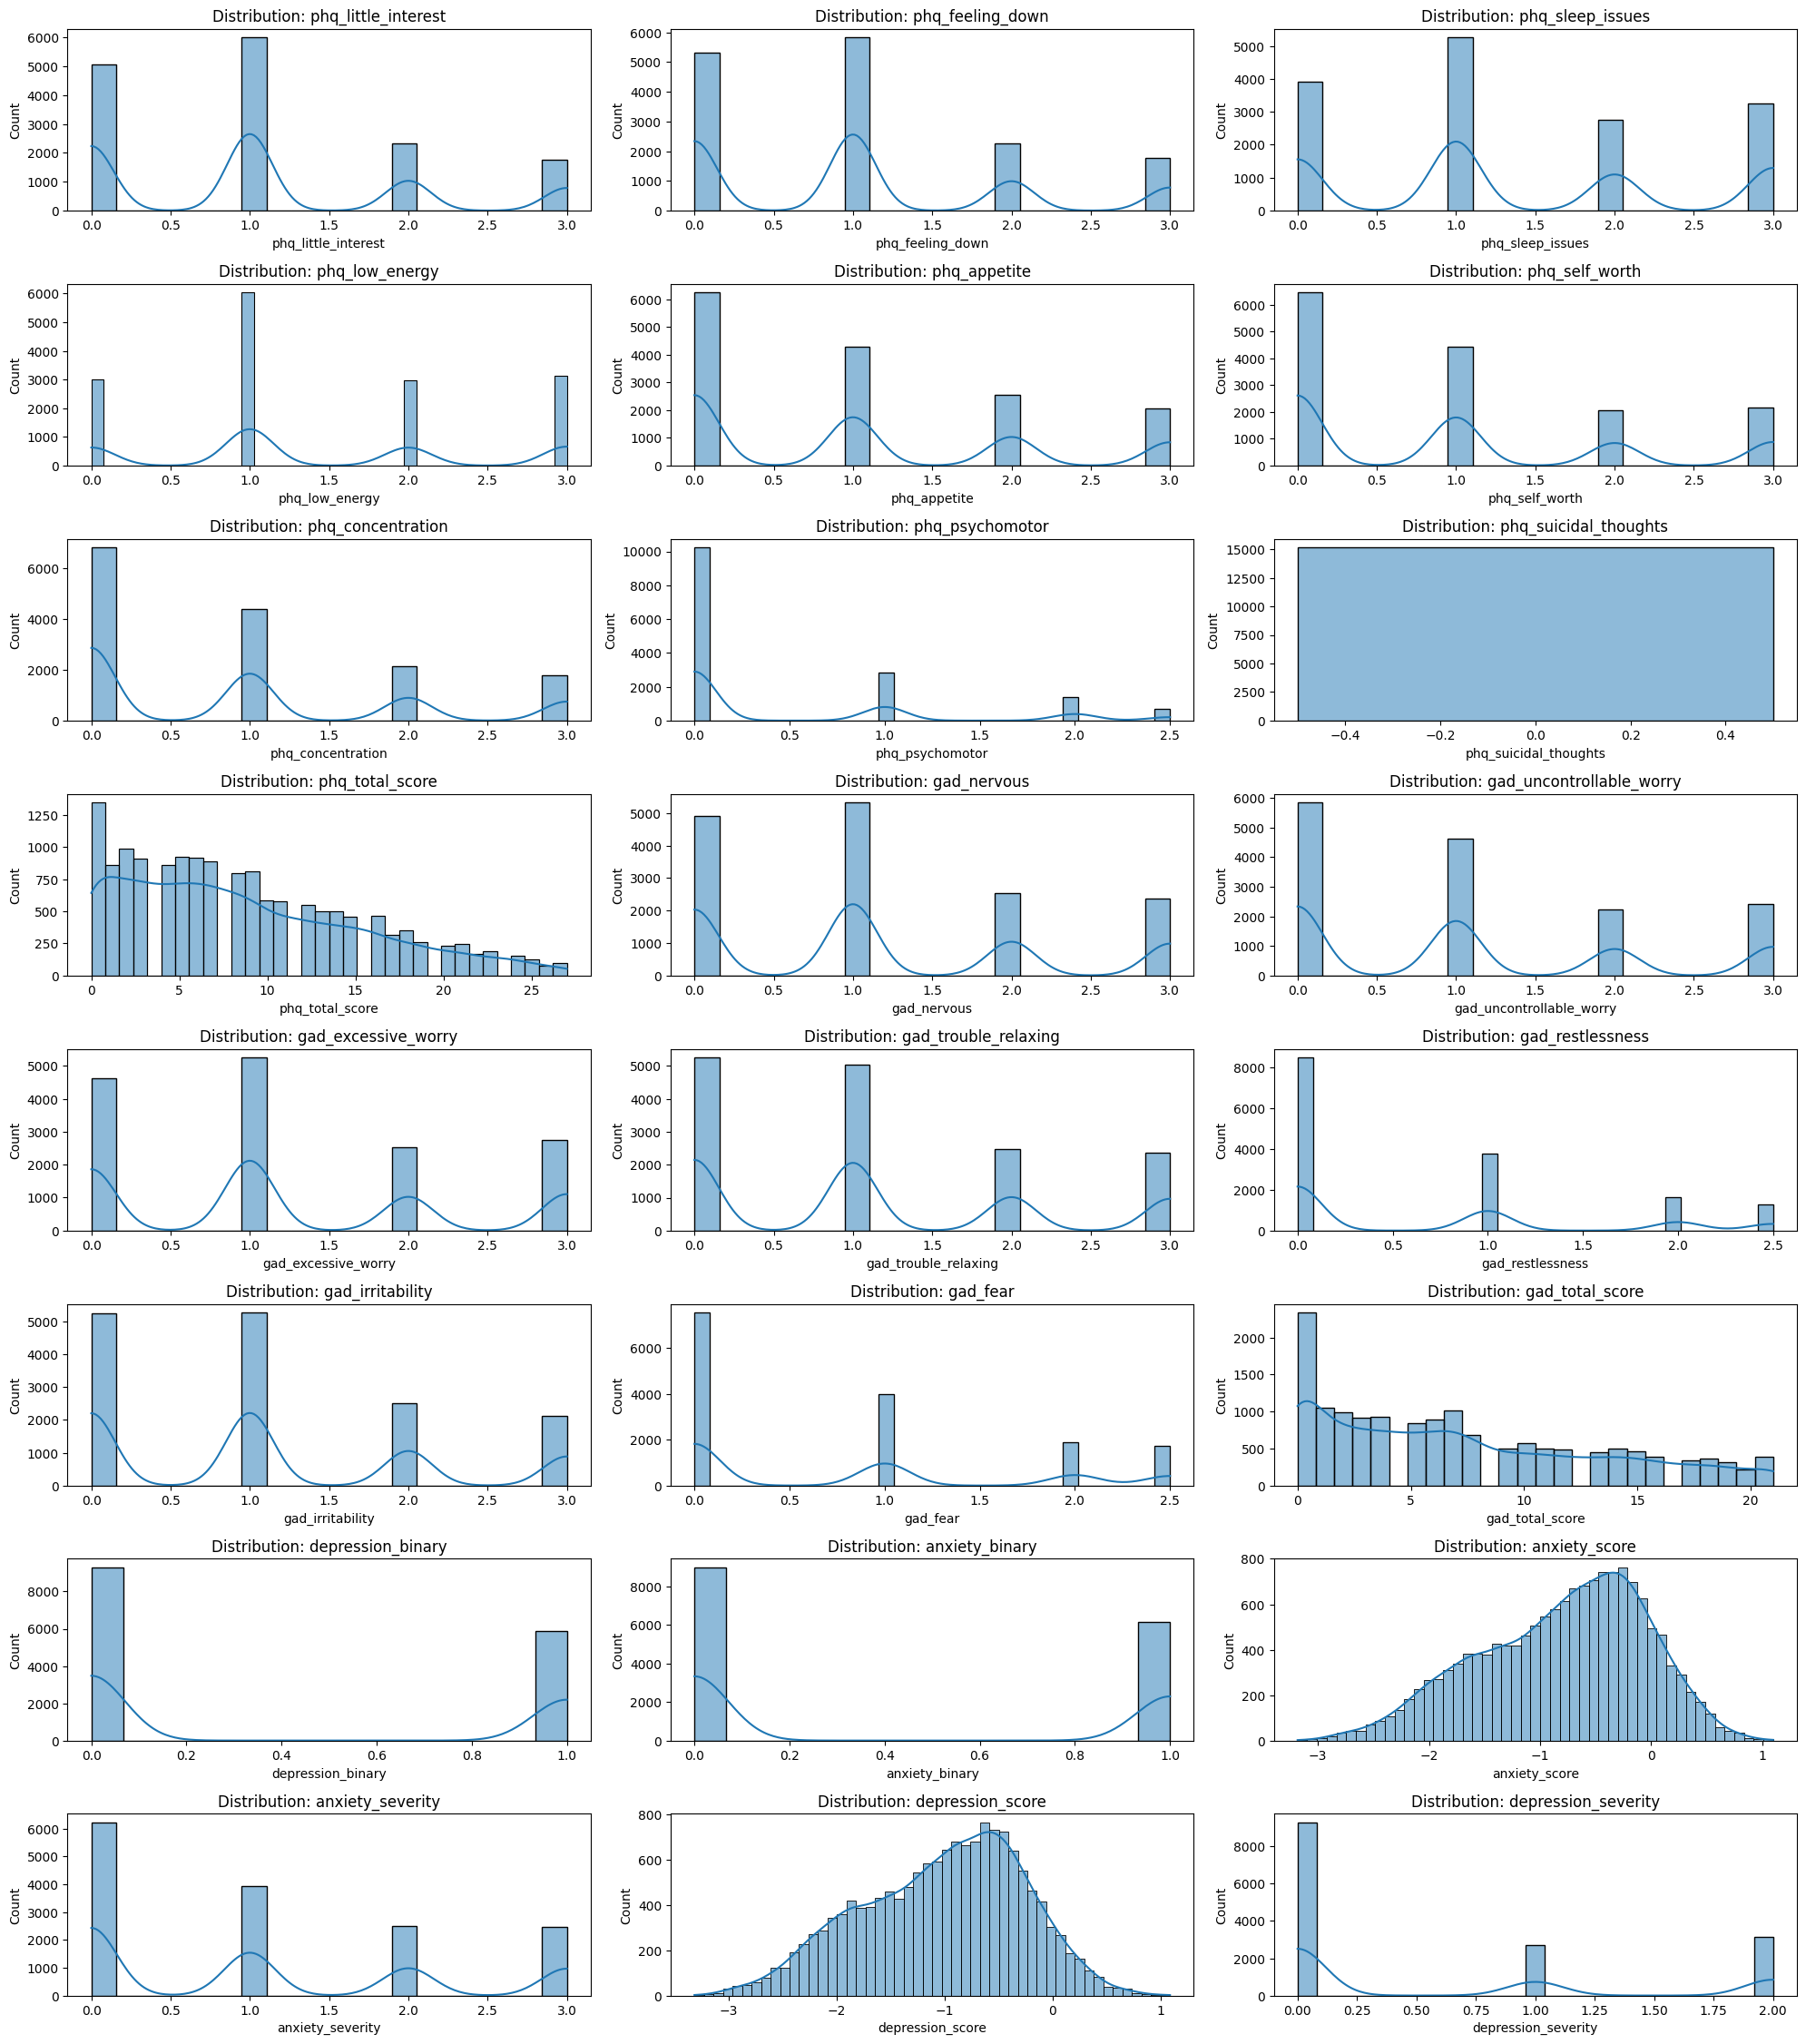

In [33]:
# Distribution Plot
num_cols = df.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(20,25))

for i, col in enumerate(num_cols):
    plt.subplot((len(num_cols)//3)+1, 3, i+1)
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution: {col}")

plt.tight_layout()
plt.show()

In [34]:
df.drop(columns=["depression_binary", "anxiety_binary"], inplace=True)

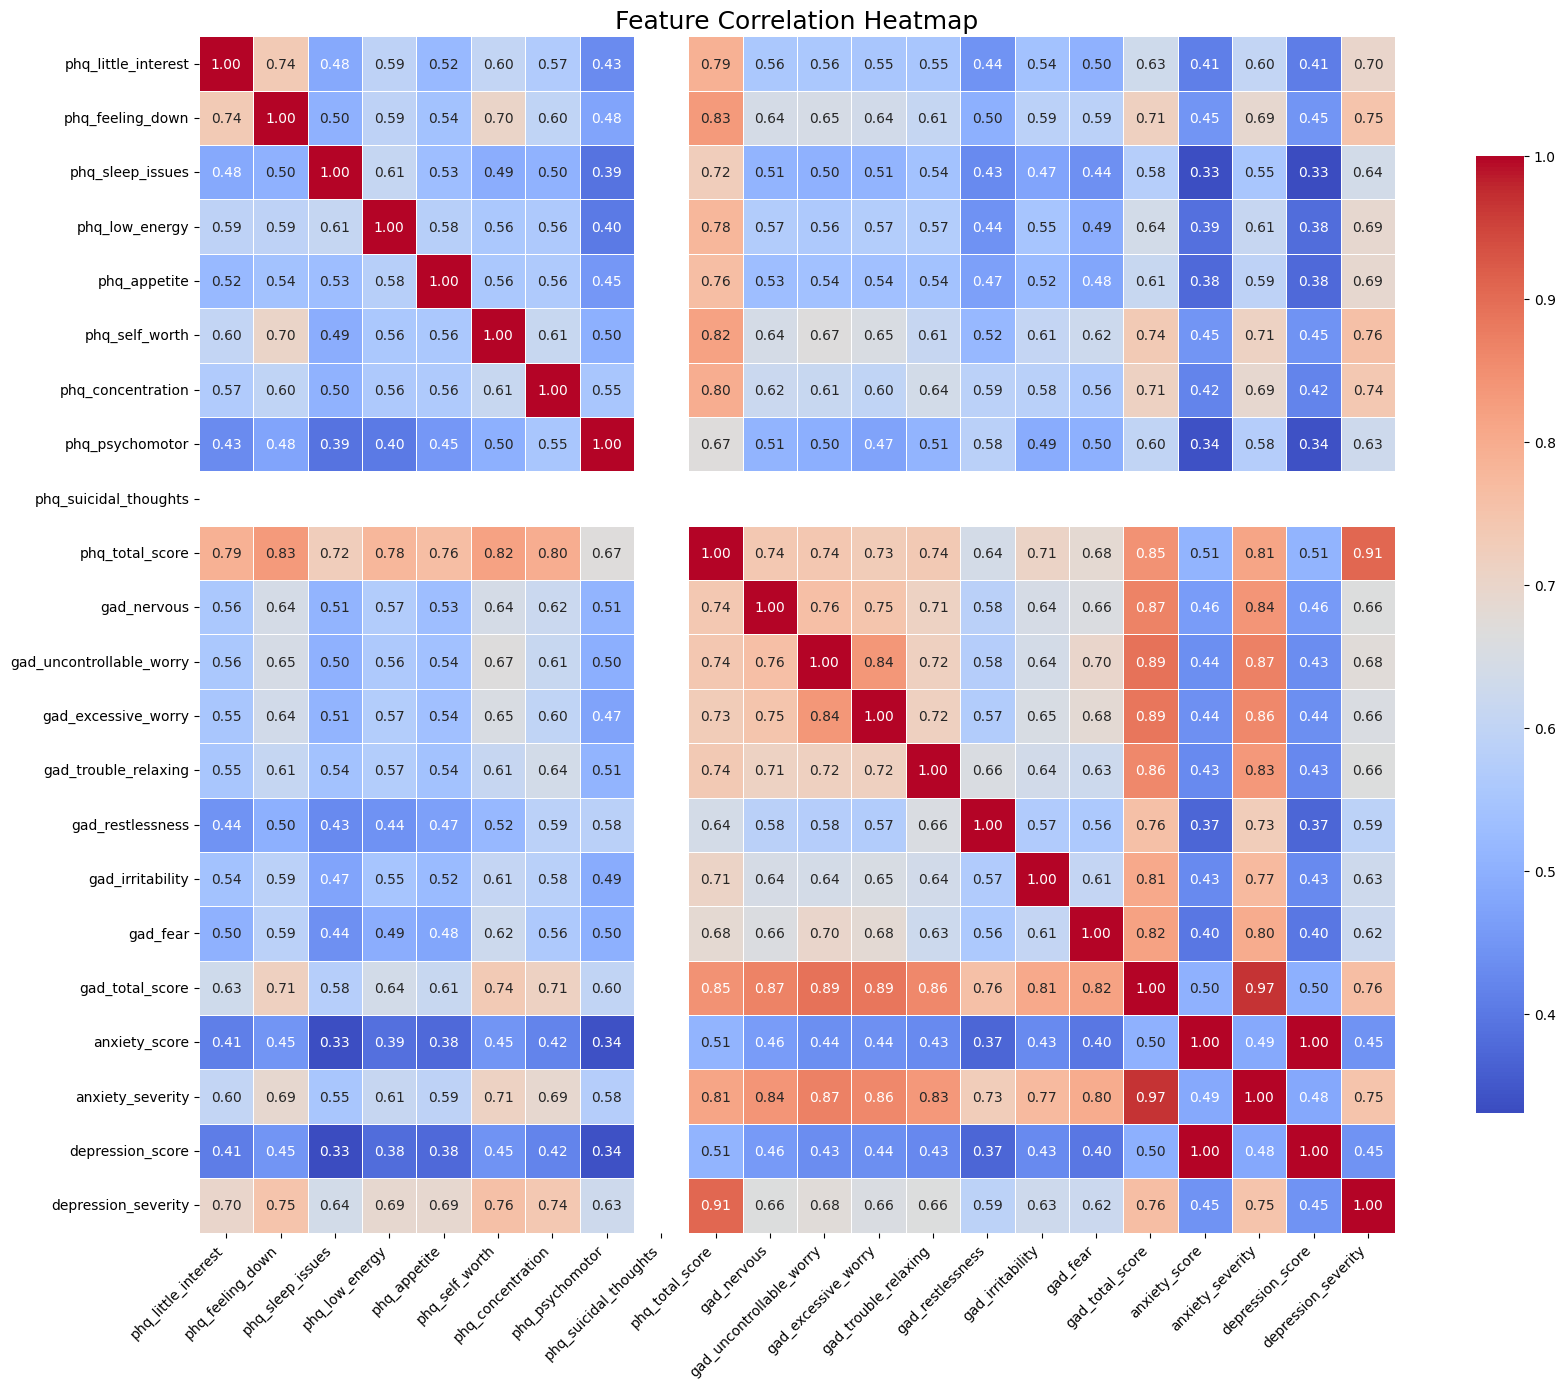

In [35]:
# Heat Map

# compute correlation
corr = df.corr(numeric_only=True)

plt.figure(figsize=(18,14))

sns.heatmap(
    corr,
    annot=True,              # shows correlation values
    fmt=".2f",               # 2 decimal points
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": .8}
)

plt.title("Feature Correlation Heatmap", fontsize=18)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

In [36]:
df = df.drop(columns=[
    "anxiety_score",
    "depression_score"
])

In [37]:
df.columns

Index(['phq_little_interest', 'phq_feeling_down', 'phq_sleep_issues',
       'phq_low_energy', 'phq_appetite', 'phq_self_worth', 'phq_concentration',
       'phq_psychomotor', 'phq_suicidal_thoughts', 'phq_total_score',
       'gad_nervous', 'gad_uncontrollable_worry', 'gad_excessive_worry',
       'gad_trouble_relaxing', 'gad_restlessness', 'gad_irritability',
       'gad_fear', 'gad_total_score', 'anxiety_severity',
       'depression_severity'],
      dtype='object')

In [38]:
X = df.drop(columns=["depression_severity","anxiety_severity"])

In [39]:
y_dep = df["depression_severity"]
y_anx = df["anxiety_severity"]

# Feature Scaling

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train Test Split

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_dep_train, y_dep_test = train_test_split(
    X_scaled, y_dep, test_size=0.2, random_state=42)

X_train2, X_test2, y_anx_train, y_anx_test = train_test_split(
    X_scaled, y_anx, test_size=0.2, random_state=42)

# ML Model Building

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# Logistic Regression

In [43]:
log_dep = LogisticRegression(max_iter=500)
log_dep.fit(X_train, y_dep_train)

pred_log_dep = log_dep.predict(X_test)

print("Logistic Regression (Depression)")
print("Accuracy:", accuracy_score(y_dep_test, pred_log_dep))
print(classification_report(y_dep_test, pred_log_dep))

Logistic Regression (Depression)
Accuracy: 0.9947194719471947
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1886
           1       0.99      0.98      0.99       546
           2       1.00      0.99      0.99       598

    accuracy                           0.99      3030
   macro avg       0.99      0.99      0.99      3030
weighted avg       0.99      0.99      0.99      3030



In [44]:
print("Training accuracy:", log_dep.score(X_train, y_dep_train))
print("Testing accuracy :", log_dep.score(X_test, y_dep_test))

Training accuracy: 0.9953783939919122
Testing accuracy : 0.9947194719471947


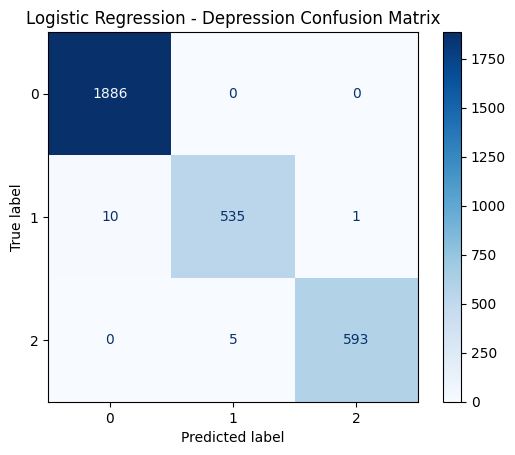

In [45]:
cm = confusion_matrix(y_dep_test, pred_log_dep)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")
plt.title("Logistic Regression - Depression Confusion Matrix")
plt.show()

In [46]:
log_anx = LogisticRegression(max_iter=500)
log_anx.fit(X_train2, y_anx_train)

pred_log_anx = log_anx.predict(X_test2)

print("Logistic Regression (Anxiety)")
print("Accuracy:", accuracy_score(y_anx_test, pred_log_anx))
print(classification_report(y_anx_test, pred_log_anx))

Logistic Regression (Anxiety)
Accuracy: 0.9996699669966996
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1214
           1       1.00      1.00      1.00       829
           2       1.00      1.00      1.00       496
           3       1.00      1.00      1.00       491

    accuracy                           1.00      3030
   macro avg       1.00      1.00      1.00      3030
weighted avg       1.00      1.00      1.00      3030



In [47]:
print("Training accuracy:", log_anx.score(X_train2, y_anx_train))
print("Testing accuracy :", log_anx.score(X_test2, y_anx_test))

Training accuracy: 0.9998349426425683
Testing accuracy : 0.9996699669966996


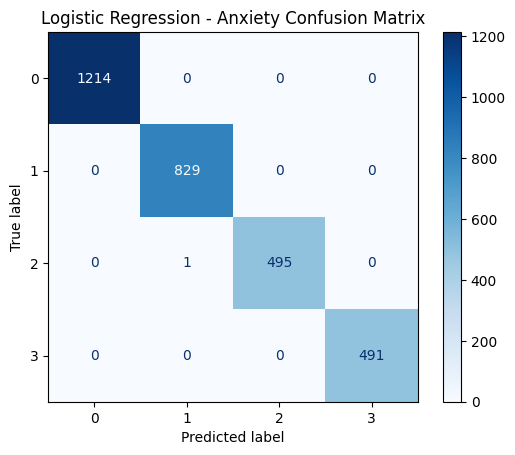

In [48]:
cm = confusion_matrix(y_anx_test, pred_log_anx)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")
plt.title("Logistic Regression - Anxiety Confusion Matrix")
plt.show()

# Random Forest

In [49]:
rf_dep = RandomForestClassifier(n_estimators=200, random_state=42)
rf_dep.fit(X_train, y_dep_train)

pred_rf_dep = rf_dep.predict(X_test)

print("Random Forest (Depression)")
print("Accuracy:", accuracy_score(y_dep_test, pred_rf_dep))
print(classification_report(y_dep_test, pred_rf_dep))

Random Forest (Depression)
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1886
           1       1.00      1.00      1.00       546
           2       1.00      1.00      1.00       598

    accuracy                           1.00      3030
   macro avg       1.00      1.00      1.00      3030
weighted avg       1.00      1.00      1.00      3030



In [50]:
print("Training accuracy:", rf_dep.score(X_train, y_dep_train))
print("Testing accuracy :", rf_dep.score(X_test, y_dep_test))

Training accuracy: 1.0
Testing accuracy : 1.0


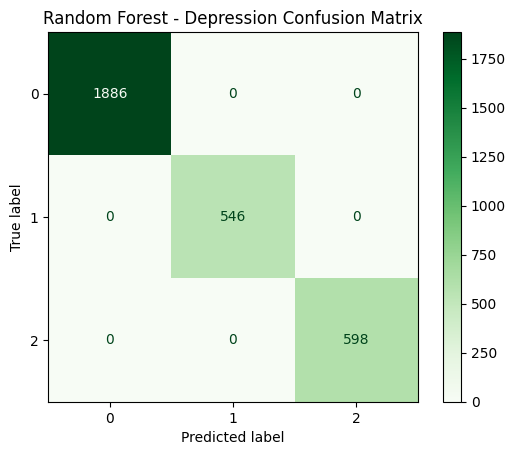

In [51]:
cm = confusion_matrix(y_dep_test, pred_rf_dep)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Greens")
plt.title("Random Forest - Depression Confusion Matrix")
plt.show()

In [52]:
rf_anx = RandomForestClassifier(n_estimators=200, random_state=42)
rf_anx.fit(X_train2, y_anx_train)

pred_rf_anx = rf_anx.predict(X_test2)

print("Random Forest (Anxiety)")
print("Accuracy:", accuracy_score(y_anx_test, pred_rf_anx))
print(classification_report(y_anx_test, pred_rf_anx))

Random Forest (Anxiety)
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1214
           1       1.00      1.00      1.00       829
           2       1.00      1.00      1.00       496
           3       1.00      1.00      1.00       491

    accuracy                           1.00      3030
   macro avg       1.00      1.00      1.00      3030
weighted avg       1.00      1.00      1.00      3030



In [53]:
print("Training accuracy:", rf_anx.score(X_train2, y_anx_train))
print("Testing accuracy :", rf_anx.score(X_test2, y_anx_test))

Training accuracy: 1.0
Testing accuracy : 1.0


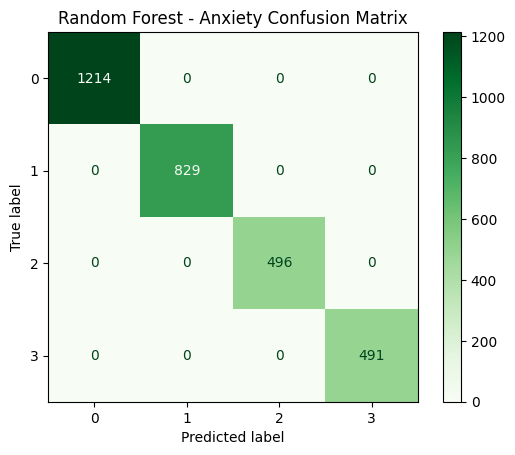

In [54]:
cm = confusion_matrix(y_anx_test, pred_rf_anx)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Greens")
plt.title("Random Forest - Anxiety Confusion Matrix")
plt.show()

# XGBoost

In [55]:
xgb_dep = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb_dep.fit(X_train, y_dep_train)

pred_xgb_dep = xgb_dep.predict(X_test)

print("XGBoost (Depression)")
print("Accuracy:", accuracy_score(y_dep_test, pred_xgb_dep))
print(classification_report(y_dep_test, pred_xgb_dep))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:51:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost (Depression)
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1886
           1       1.00      1.00      1.00       546
           2       1.00      1.00      1.00       598

    accuracy                           1.00      3030
   macro avg       1.00      1.00      1.00      3030
weighted avg       1.00      1.00      1.00      3030



In [56]:
print("Training accuracy:", xgb_dep.score(X_train, y_dep_train))
print("Testing accuracy :", xgb_dep.score(X_test, y_dep_test))

Training accuracy: 1.0
Testing accuracy : 1.0


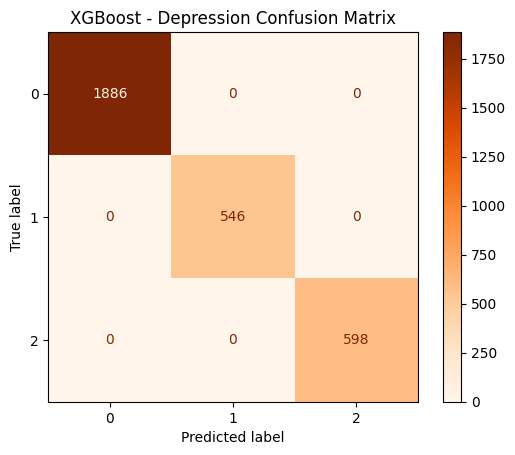

In [57]:
cm = confusion_matrix(y_dep_test, pred_xgb_dep)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Oranges")
plt.title("XGBoost - Depression Confusion Matrix")
plt.show()

In [58]:
xgb_anx = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb_anx.fit(X_train2, y_anx_train)

pred_xgb_anx = xgb_anx.predict(X_test2)

print("XGBoost (Anxiety)")
print("Accuracy:", accuracy_score(y_anx_test, pred_xgb_anx))
print(classification_report(y_anx_test, pred_xgb_anx))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:51:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost (Anxiety)
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1214
           1       1.00      1.00      1.00       829
           2       1.00      1.00      1.00       496
           3       1.00      1.00      1.00       491

    accuracy                           1.00      3030
   macro avg       1.00      1.00      1.00      3030
weighted avg       1.00      1.00      1.00      3030



In [59]:
print("Training accuracy:", xgb_anx.score(X_train2, y_anx_train))
print("Testing accuracy :", xgb_anx.score(X_test2, y_anx_test))

Training accuracy: 1.0
Testing accuracy : 1.0


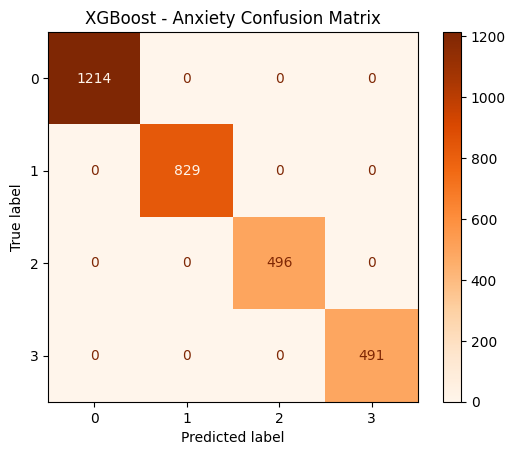

In [60]:
cm = confusion_matrix(y_anx_test, pred_xgb_anx)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Oranges")
plt.title("XGBoost - Anxiety Confusion Matrix")
plt.show()

# Cross-Validation

In [61]:
from sklearn.model_selection import cross_val_score

In [62]:
log_dep_model = LogisticRegression(max_iter=500)

cv_log_dep = cross_val_score(log_dep_model, X_scaled, y_dep, cv=5)

print("Logistic Regression CV (Depression):", cv_log_dep)
print("Average:", cv_log_dep.mean())

Logistic Regression CV (Depression): [0.9960396  0.99570957 0.99504787 0.99174645 0.99768901]
Average: 0.9952465005496919


In [63]:
rf_dep_model = RandomForestClassifier(n_estimators=200, random_state=42)

cv_rf_dep = cross_val_score(rf_dep_model, X_scaled, y_dep, cv=5)

print("Random Forest CV (Depression):", cv_rf_dep)
print("Average:", cv_rf_dep.mean())

Random Forest CV (Depression): [1. 1. 1. 1. 1.]
Average: 1.0


In [64]:
xgb_dep_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')

cv_xgb_dep = cross_val_score(xgb_dep_model, X_scaled, y_dep, cv=5)

print("XGBoost CV (Depression):", cv_xgb_dep)
print("Average:", cv_xgb_dep.mean())

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:51:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:51:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:51:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:51:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

XGBoost CV (Depression): [1. 1. 1. 1. 1.]
Average: 1.0


In [65]:
log_anx_model = LogisticRegression(max_iter=500)

cv_log_anx = cross_val_score(log_anx_model, X_scaled, y_anx, cv=5)

print("Logistic Regression CV (Anxiety):", cv_log_anx)
print("Average:", cv_log_anx.mean())

Logistic Regression CV (Anxiety): [0.9990099  1.         0.99735886 0.99966986 1.        ]
Average: 0.9992077246681419


In [66]:
rf_anx_model = RandomForestClassifier(n_estimators=200, random_state=42)

cv_rf_anx = cross_val_score(rf_anx_model, X_scaled, y_anx, cv=5)

print("Random Forest CV (Anxiety):", cv_rf_anx)
print("Average:", cv_rf_anx.mean())


Random Forest CV (Anxiety): [1. 1. 1. 1. 1.]
Average: 1.0


In [67]:
xgb_anx_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')

cv_xgb_anx = cross_val_score(xgb_anx_model, X_scaled, y_anx, cv=5)

print("XGBoost CV (Anxiety):", cv_xgb_anx)
print("Average:", cv_xgb_anx.mean())

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:52:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:52:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:52:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:52:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

XGBoost CV (Anxiety): [1. 1. 1. 1. 1.]
Average: 1.0


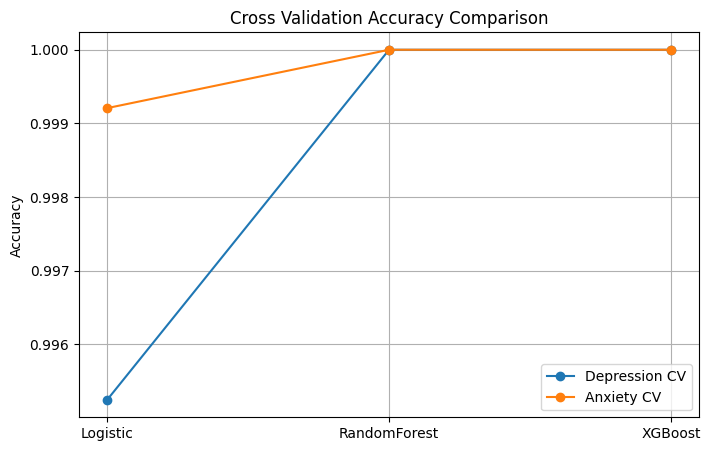

In [68]:
models = ["Logistic", "RandomForest", "XGBoost"]

dep_scores = [
    cv_log_dep.mean(),
    cv_rf_dep.mean(),
    cv_xgb_dep.mean()
]

anx_scores = [
    cv_log_anx.mean(),
    cv_rf_anx.mean(),
    cv_xgb_anx.mean()
]

plt.figure(figsize=(8,5))
plt.plot(models, dep_scores, marker='o', label="Depression CV")
plt.plot(models, anx_scores, marker='o', label="Anxiety CV")

plt.title("Cross Validation Accuracy Comparison")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Saving Best Model

In [69]:
import joblib

In [70]:
joblib.dump(rf_dep, "depression_model.pkl")

['depression_model.pkl']

In [71]:
joblib.dump(rf_anx, "anxiety_model.pkl")

['anxiety_model.pkl']